In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import sys
sys.path.append('..')

from src.network import Network
from src.layers import Dense
from src.activations import ReLU, Softmax
from src.losses import CrossEntropyLoss

In [3]:
print("Pobieranie MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

X = X / 255.0

y_onehot = np.zeros((len(y), 10))
y_onehot[np.arange(len(y)), y] = 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Pobieranie MNIST...
Train: (56000, 784), Test: (14000, 784)


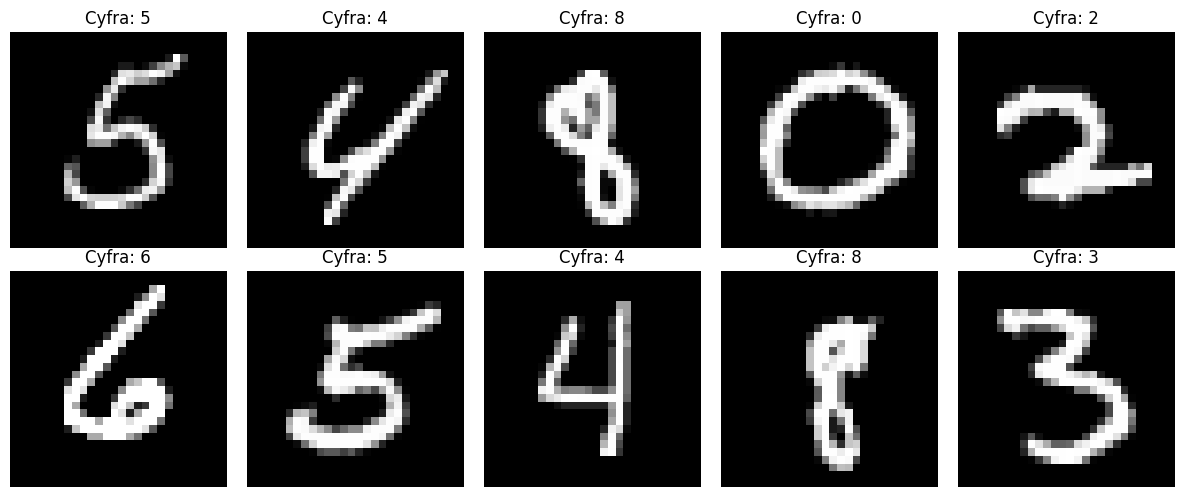

In [4]:
# Podgląd kilku cyfr
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Cyfra: {np.argmax(y_train[i])}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
model = Network()
model.add(Dense(784, 128))
model.add(ReLU())
model.add(Dense(128, 64))
model.add(ReLU())
model.add(Dense(64, 10))
model.add(Softmax())

model.train(X_train, y_train, epochs=100, lr=0.01, batch_size=32)

Epoch   0 | loss: 0.3139 | acc: 0.9109
Epoch  10 | loss: 0.0932 | acc: 0.9730
Epoch  20 | loss: 0.0489 | acc: 0.9870
Epoch  30 | loss: 0.0297 | acc: 0.9928
Epoch  40 | loss: 0.0185 | acc: 0.9970
Epoch  50 | loss: 0.0122 | acc: 0.9982
Epoch  60 | loss: 0.0083 | acc: 0.9993
Epoch  70 | loss: 0.0054 | acc: 0.9998
Epoch  80 | loss: 0.0042 | acc: 0.9998
Epoch  90 | loss: 0.0032 | acc: 1.0000


In [6]:
y_pred_test = model.forward(X_test)
test_acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test, axis=1))
print(f"Accuracy na danych testowych: {test_acc:.4f}")

Accuracy na danych testowych: 0.9759


In [7]:
model2 = Network()
model2.add(Dense(784, 128))
model2.add(ReLU())
model2.add(Dense(128, 64))
model2.add(ReLU())
model2.add(Dense(64, 10))
model2.add(Softmax())

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(100):
    # Trening
    indices = np.random.permutation(len(X_train))
    for i in range(0, len(X_train), 32):
        idx = indices[i:i+32]
        x_batch = X_train[idx]
        y_batch = y_train[idx]
        y_pred = model2.forward(x_batch)
        grad = (y_pred - y_batch) / len(y_batch)
        model2.backward(grad)
        model2.update(0.01)

    # Metryki co epokę
    y_pred_train = model2.forward(X_train)
    y_pred_test = model2.forward(X_test)

    train_loss = -np.mean(np.sum(y_train * np.log(np.clip(y_pred_train, 1e-7, 1-1e-7)), axis=1))
    test_loss = -np.mean(np.sum(y_test * np.log(np.clip(y_pred_test, 1e-7, 1-1e-7)), axis=1))
    train_acc = np.mean(np.argmax(y_pred_train, axis=1) == np.argmax(y_train, axis=1))
    test_acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test, axis=1))

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | test_acc: {test_acc:.4f}")

Epoch   0 | train_loss: 0.3100 | test_acc: 0.9094
Epoch  10 | train_loss: 0.0887 | test_acc: 0.9633
Epoch  20 | train_loss: 0.0466 | test_acc: 0.9706
Epoch  30 | train_loss: 0.0273 | test_acc: 0.9734
Epoch  40 | train_loss: 0.0168 | test_acc: 0.9740
Epoch  50 | train_loss: 0.0111 | test_acc: 0.9732
Epoch  60 | train_loss: 0.0071 | test_acc: 0.9740
Epoch  70 | train_loss: 0.0052 | test_acc: 0.9745
Epoch  80 | train_loss: 0.0038 | test_acc: 0.9741
Epoch  90 | train_loss: 0.0030 | test_acc: 0.9753


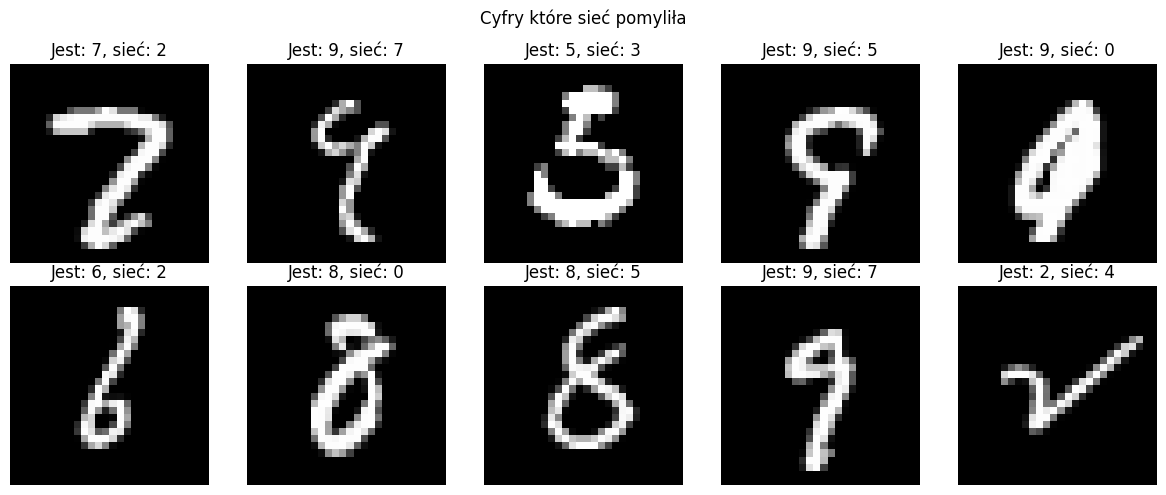

In [9]:
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
mistakes = np.where(y_pred_labels != y_true_labels)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = mistakes[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Jest: {y_true_labels[idx]}, sieć: {y_pred_labels[idx]}")
    ax.axis('off')
plt.suptitle("Cyfry które sieć pomyliła")
plt.tight_layout()
plt.show()

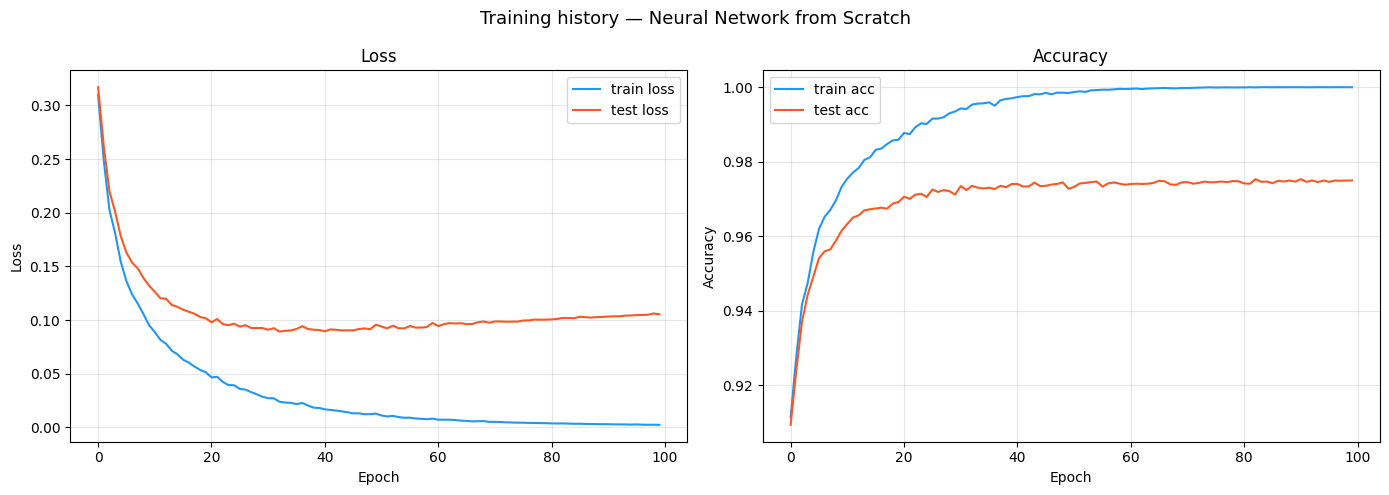

Wykres zapisany do assets/training_history.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='train loss', color='#2196F3')
ax1.plot(history['test_loss'], label='test loss', color='#FF5722')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='train acc', color='#2196F3')
ax2.plot(history['test_acc'], label='test acc', color='#FF5722')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training history — Neural Network from Scratch', fontsize=13)
plt.tight_layout()
plt.savefig('../assets/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Wykres zapisany do assets/training_history.png")